In [2]:
#imporint module 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
# loading date
df = pd.read_csv("Reliance_EDA.csv")

# setting the index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-01-03,33.917892,35.945827,33.917892,35.945827,26.684866,31204789.0
2000-01-04,36.902668,38.823490,35.888702,38.823490,28.821142,66436055.0
2000-01-05,36.652744,41.115627,36.652744,40.344440,29.950235,187894923.0
2000-01-06,41.272720,42.943623,41.272720,42.036766,31.206556,109810562.0
2000-01-07,42.129593,45.399994,41.843967,44.921570,33.348133,139140630.0


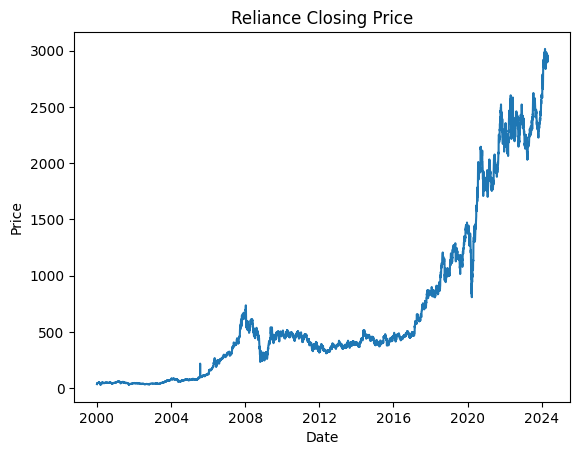

In [4]:
plt.figure()
plt.plot(df['Close'])
plt.title("Reliance Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [5]:
# Data split 
test_size = 252

train = df[:-test_size]
test = df[-test_size:]

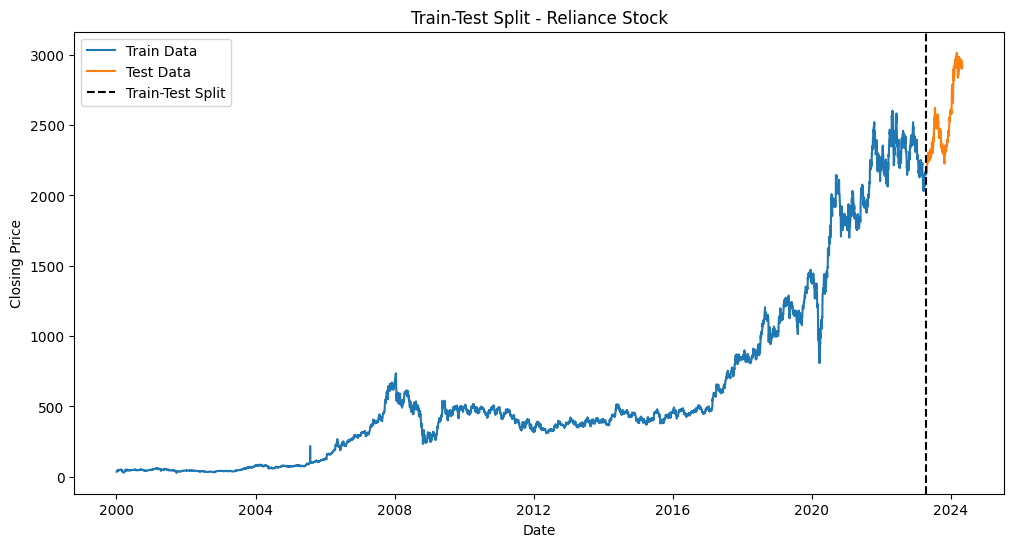

In [6]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train['Close'], label='Train Data')
plt.plot(test.index, test['Close'], label='Test Data')

plt.axvline(x=test.index[0], color='black', linestyle='--', 
            label='Train-Test Split')

plt.title('Train-Test Split - Reliance Stock')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()

plt.show()

In [7]:
# Starndardizing 
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[['Close']])
test_scaled = scaler.transform(test[['Close']])

In [8]:
# It converts time-series data into supervised learning format.

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

window_size = 60

X_train, y_train = create_sequences(train_scaled, window_size)

combined = np.vstack((train_scaled[-window_size:], test_scaled))
X_test, y_test = create_sequences(combined, window_size)

In [9]:
# building a model 
model = Sequential() #Creates a stacked layer model.

model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2)) # Randomly drops 20% neurons during training to prevents overfitting.

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

2026-03-03 18:12:12.906333: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-03 18:12:12.906412: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-03 18:12:12.906424: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-03 18:12:12.906479: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-03 18:12:12.906496: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Model fitting  
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20


2026-03-03 18:12:13.814505: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0028 - val_loss: 0.0046
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0010 - val_loss: 0.0040
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0010 - val_loss: 0.0049
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.0033e-04 - val_loss: 6.3528e-04
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.0989e-04 - val_loss: 0.0076
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2184e-04 - val_loss: 0.0025
Epoch 7/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.8513e-04 - val_loss: 0.0025
Epoch 8/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.3483e-04 - val_loss: 3.7916e-04
Epoch 9/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.5137e-04 - val_loss: 5.3435e-04
Epoch 10/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.1090e-04 - val_loss: 0.0020
Epoch 11/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.7844e-04 - val_loss: 0.0040
Epoch 12

In [11]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
r2 = r2_score(y_test_actual, predictions)

print("RMSE:", rmse)
print("R2 Score:", r2)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
RMSE: 108.64095806099189
R2 Score: 0.80888362611062


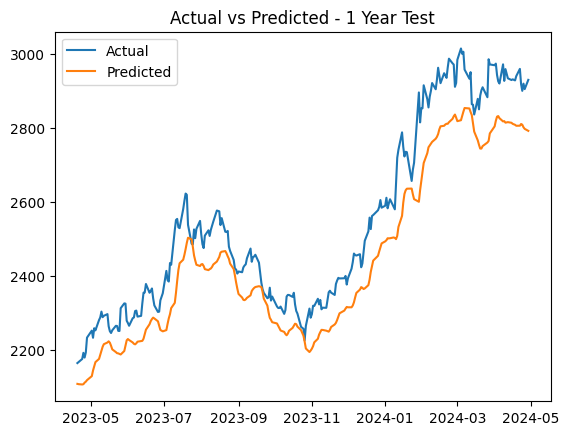

In [12]:
plt.figure()
plt.plot(test.index, y_test_actual, label='Actual')
plt.plot(test.index, predictions, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted - 1 Year Test")
plt.show()

In [13]:
future_days = 252
last_window = combined[-window_size:]
future_predictions = []

for _ in range(future_days):
    pred = model.predict(last_window.reshape(1, window_size, 1))
    future_predictions.append(pred[0][0])
    last_window = np.append(last_window[1:], pred, axis=0)

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━

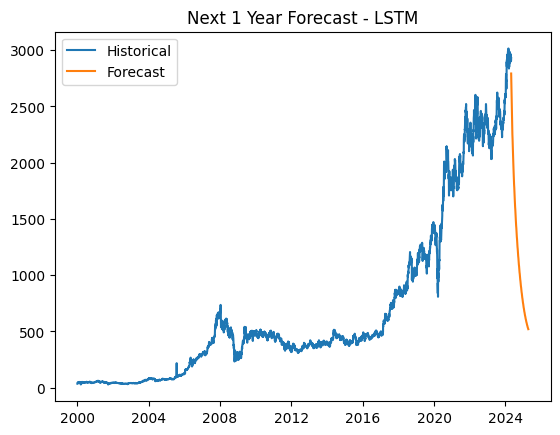

In [14]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=future_days,
    freq='B'
)
plt.figure()
plt.plot(df.index, df['Close'], label='Historical')
plt.plot(future_dates, future_predictions, label='Forecast')
plt.legend()
plt.title("Next 1 Year Forecast - LSTM")
plt.show()

In [15]:
future_dates

DatetimeIndex(['2024-04-29', '2024-04-30', '2024-05-01', '2024-05-02',
               '2024-05-03', '2024-05-06', '2024-05-07', '2024-05-08',
               '2024-05-09', '2024-05-10',
               ...
               '2025-04-02', '2025-04-03', '2025-04-04', '2025-04-07',
               '2025-04-08', '2025-04-09', '2025-04-10', '2025-04-11',
               '2025-04-14', '2025-04-15'],
              dtype='datetime64[us]', length=252, freq='B')

In [16]:
future_predictions.shape

(252, 1)

In [17]:
df_close=pd.DataFrame(future_predictions)

In [18]:
Future_price = pd.DataFrame()


In [19]:
Future_price["Close"]=pd.DataFrame(future_predictions)

In [20]:
Future_price["Date"]=pd.DataFrame(future_dates)
Future_price.set_index('Date', inplace=True)
Future_price

,Close
Date,
2024-04-29,2792.389648
2024-04-30,2769.515137
2024-05-01,2739.187744
2024-05-02,2705.466309
2024-05-03,2670.786133
...,...
2025-04-09,528.595337
2025-04-10,526.527954
2025-04-11,524.482666


In [21]:
Future_price.to_csv("Future price 2024-04-30 to 2025-04-16" )

In [23]:
import pickle

# Save model
model.save("lstm_model.keras")

# Save scaler separately
pickle.dump(scaler, open("scaler.pkl", "wb"))